<a href="https://colab.research.google.com/github/VenkataGouthamReddy/192324265_ITA0604-Machine_Learning/blob/main/assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========== DECISION TREE RULES ==========
|--- Chlorine <= 1.50
|   |--- class: Needs Treatment
|--- Chlorine >  1.50
|   |--- pH_band <= 1.50
|   |   |--- class: Needs Treatment
|   |--- pH_band >  1.50
|   |   |--- Turbidity <= 0.50
|   |   |   |--- class: Needs Treatment
|   |   |--- Turbidity >  0.50
|   |   |   |--- Microbial <= 0.50
|   |   |   |   |--- class: Safe
|   |   |   |--- Microbial >  0.50
|   |   |   |   |--- class: Needs Treatment

========== EVALUATION METRICS ==========
Confusion Matrix:
[[ 8  0]
 [ 0 37]]

Accuracy:  1.00
Precision: 1.00
Recall:    1.00
F1-Score:  1.00

========== GENERATING TREE DIAGRAM ==========
Tree diagram successfully saved as 'decision_tree_diagram.png'!


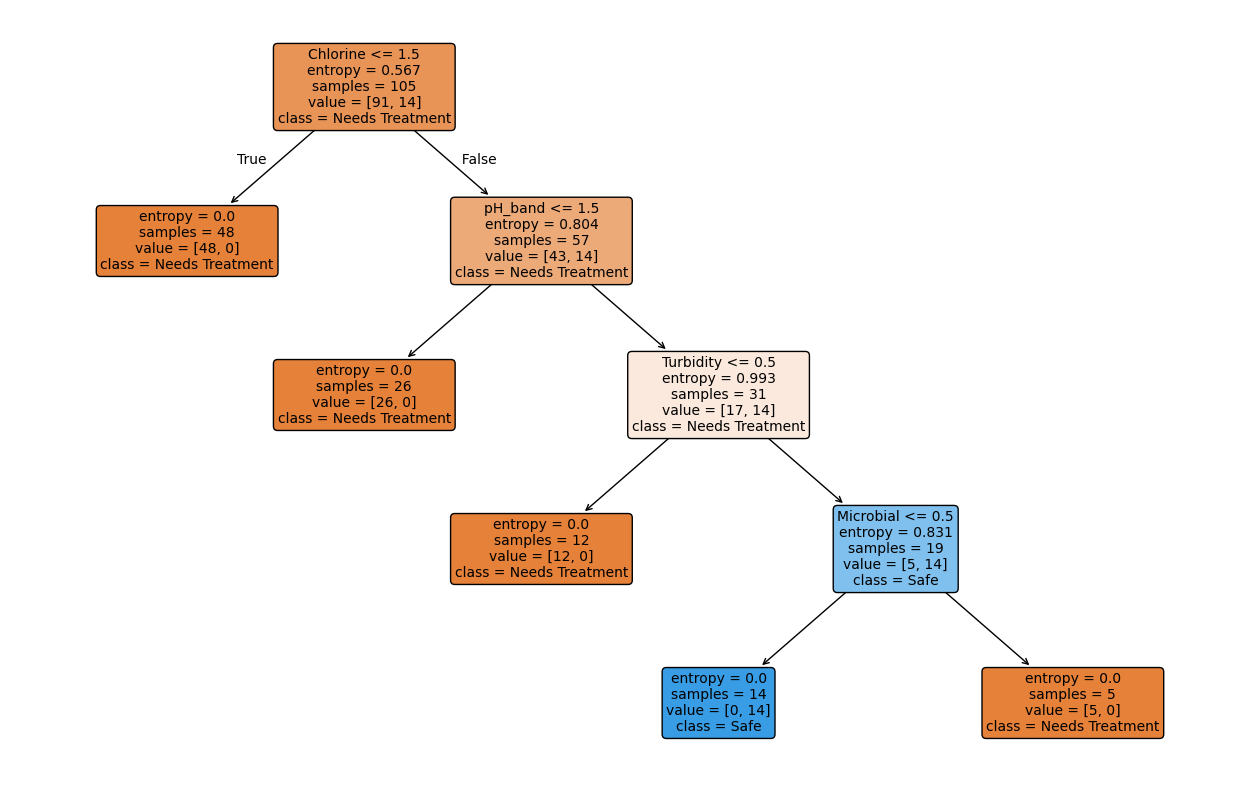

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

# 1. Generate Synthetic Dataset (150 records)
np.random.seed(42)
data_size = 150

# Generate 6 features based on assignment requirements
data = {
    'pH_band': np.random.choice(['Acidic', 'Neutral', 'Alkaline'], data_size, p=[0.2, 0.6, 0.2]),
    'Turbidity': np.random.choice(['Low', 'High'], data_size, p=[0.7, 0.3]),
    'TDS_band': np.random.choice(['Low', 'Medium', 'High'], data_size, p=[0.4, 0.4, 0.2]),
    'Chlorine': np.random.choice(['Low', 'Normal', 'High'], data_size, p=[0.2, 0.6, 0.2]),
    'Microbial': np.random.choice(['Absent', 'Present'], data_size, p=[0.8, 0.2]),
    'Source': np.random.choice(['Groundwater', 'Surface', 'Rainwater'], data_size)
}

df = pd.DataFrame(data)

# Define Target Concept:
# Water is "Safe" IF (pH is Neutral) AND (Turbidity is Low) AND (Chlorine is Normal) AND (Microbes are Absent)
def determine_class(row):
    if (row['pH_band'] == 'Neutral' and
        row['Turbidity'] == 'Low' and
        row['Chlorine'] == 'Normal' and
        row['Microbial'] == 'Absent'):
        return 'Safe'
    return 'Needs Treatment'

df['Class'] = df.apply(determine_class, axis=1)

# 2. Preprocessing
# Convert categorical text into numerical labels for the Decision Tree
label_encoders = {}
df_encoded = df.copy()

for column in df.columns:
    if column != 'Class':
        le = LabelEncoder()
        df_encoded[column] = le.fit_transform(df[column])
        label_encoders[column] = le

# Separate features (X) and target (y)
X = df_encoded.drop('Class', axis=1)
y = df['Class'] # Keeping target as string for readable output

# 3. Train/Test Split (70% Train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. Model Training using Entropy (Information Gain)
dt_classifier = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
dt_classifier.fit(X_train, y_train)

# 5. Output Interpretable Decision Tree Rules
print("========== DECISION TREE RULES ==========")
tree_rules = export_text(dt_classifier, feature_names=list(X.columns))
print(tree_rules)

# 6. Predictions & Evaluation Metrics
y_pred = dt_classifier.predict(X_test)

print("========== EVALUATION METRICS ==========")
print("Confusion Matrix:")
# Labels parameter ensures we know which row/col is 'Safe' vs 'Needs Treatment'
print(confusion_matrix(y_test, y_pred, labels=['Safe', 'Needs Treatment']))

print(f"\nAccuracy:  {accuracy_score(y_test, y_pred):.2f}")
# pos_label specifies which class is considered the "Positive" case for these metrics
print(f"Precision: {precision_score(y_test, y_pred, pos_label='Safe'):.2f}")
print(f"Recall:    {recall_score(y_test, y_pred, pos_label='Safe'):.2f}")
print(f"F1-Score:  {f1_score(y_test, y_pred, pos_label='Safe'):.2f}")
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

print("\n========== GENERATING TREE DIAGRAM ==========")
# Set the size of the figure
plt.figure(figsize=(16, 10))

# Plot the tree
plot_tree(dt_classifier,
          feature_names=list(X.columns),
          class_names=dt_classifier.classes_,
          filled=True,
          rounded=True,
          fontsize=10)

# Save the diagram as an image file in your folder
plt.savefig('decision_tree_diagram.png', dpi=300, bbox_inches='tight')
print("Tree diagram successfully saved as 'decision_tree_diagram.png'!")

# Optional: Display the tree in a pop-up window
plt.show()